# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [85]:
# Tratamiento de datos
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [69]:
df = pd.read_csv("data/nndb_flat.csv")
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [71]:
print(df.columns)
print(df.shape[1])

Index(['ID', 'FoodGroup', 'ShortDescrip', 'Descrip', 'CommonName', 'MfgName',
       'ScientificName', 'Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g',
       'Sugar_g', 'Fiber_g', 'VitA_mcg', 'VitB6_mg', 'VitB12_mcg', 'VitC_mg',
       'VitE_mg', 'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg', 'Thiamin_mg',
       'Calcium_mg', 'Copper_mcg', 'Iron_mg', 'Magnesium_mg', 'Manganese_mg',
       'Phosphorus_mg', 'Selenium_mcg', 'Zinc_mg', 'VitA_USRDA', 'VitB6_USRDA',
       'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA', 'Folate_USRDA',
       'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA', 'Calcium_USRDA',
       'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA', 'Selenium_USRDA',
       'Zinc_USRDA'],
      dtype='object')
45


In [72]:
df.dtypes

ID                    int64
FoodGroup            object
ShortDescrip         object
Descrip              object
CommonName           object
MfgName              object
ScientificName       object
Energy_kcal         float64
Protein_g           float64
Fat_g               float64
Carb_g              float64
Sugar_g             float64
Fiber_g             float64
VitA_mcg            float64
VitB6_mg            float64
VitB12_mcg          float64
VitC_mg             float64
VitE_mg             float64
Folate_mcg          float64
Niacin_mg           float64
Riboflavin_mg       float64
Thiamin_mg          float64
Calcium_mg          float64
Copper_mcg          float64
Iron_mg             float64
Magnesium_mg        float64
Manganese_mg        float64
Phosphorus_mg       float64
Selenium_mcg        float64
Zinc_mg             float64
VitA_USRDA          float64
VitB6_USRDA         float64
VitB12_USRDA        float64
VitC_USRDA          float64
VitE_USRDA          float64
Folate_USRDA        

In [73]:
'''
El dataset contiene 8.618 alimentos y 45 columnas con información nutricional.
Las primeras columnas son identificadores y descripciones (categóricas), mientras
que la mayoría son variables numéricas continuas: macronutrientes, vitaminas,
minerales y equivalentes en % de la USRDA.

Para PCA solo utilizaremos las columnas numéricas, ya que PCA requiere variables
continuas y escaladas. Las columnas categóricas (FoodGroup, Descrip, etc.) se
mantendrán solo como referencia para interpretar los componentes.
'''

'\nEl dataset contiene 8.618 alimentos y 45 columnas con información nutricional.\nLas primeras columnas son identificadores y descripciones (categóricas), mientras\nque la mayoría son variables numéricas continuas: macronutrientes, vitaminas,\nminerales y equivalentes en % de la USRDA.\n\nPara PCA solo utilizaremos las columnas numéricas, ya que PCA requiere variables\ncontinuas y escaladas. Las columnas categóricas (FoodGroup, Descrip, etc.) se\nmantendrán solo como referencia para interpretar los componentes.\n'

### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [74]:
df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


In [75]:
# las columnas '_USRDA' son proporciones respecto a la recomendación diaria y, por tanto,
# son transformaciones lineales de los nutrientes originales (VitC_mg, Calcium_mg, etc.)
# esto genera correlaciones casi perfectas y multicolinealidad extrema

# en PCA esto es problemático porque duplica la información y distorsiona la varianza
# explicada por los componentes
# así que elimino todas las columnas '_USRDA' antes de aplicar PCA

df = df.drop(columns=[col for col in df.columns if col.endswith("USRDA")])

In [76]:
df.columns

Index(['ID', 'FoodGroup', 'ShortDescrip', 'Descrip', 'CommonName', 'MfgName',
       'ScientificName', 'Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g',
       'Sugar_g', 'Fiber_g', 'VitA_mcg', 'VitB6_mg', 'VitB12_mcg', 'VitC_mg',
       'VitE_mg', 'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg', 'Thiamin_mg',
       'Calcium_mg', 'Copper_mcg', 'Iron_mg', 'Magnesium_mg', 'Manganese_mg',
       'Phosphorus_mg', 'Selenium_mcg', 'Zinc_mg'],
      dtype='object')

In [77]:
df.shape[1] # así miro con cuántas columnas me he quedado

30

### Variables no numéricas
Elimina las variables de texto del dataset

In [ ]:
# elimino las no numéricas (object/string) porque no entran en el cálculo de los PCs

df = df.select_dtypes(include=[np.number])
df.head(5)

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


In [80]:
# voy a eliminar el ID que solo estorba
df = df.drop(columns=["ID"])

In [81]:
print(df.columns)
print(df.shape[1])

Index(['Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g', 'Sugar_g', 'Fiber_g',
       'VitA_mcg', 'VitB6_mg', 'VitB12_mcg', 'VitC_mg', 'VitE_mg',
       'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg', 'Thiamin_mg', 'Calcium_mg',
       'Copper_mcg', 'Iron_mg', 'Magnesium_mg', 'Manganese_mg',
       'Phosphorus_mg', 'Selenium_mcg', 'Zinc_mg'],
      dtype='object')
23


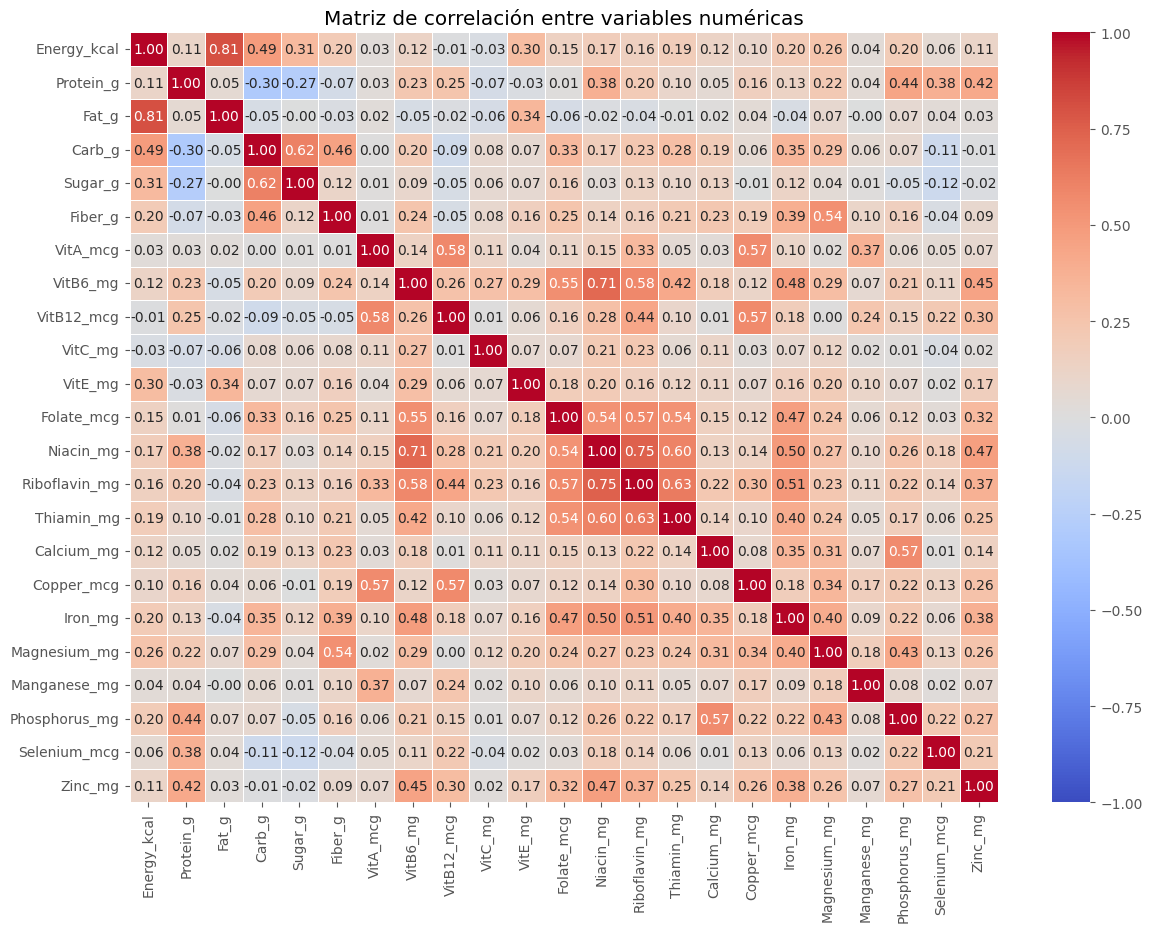

In [88]:
plt.figure(figsize=(14, 10))

corr = df.corr()

sns.heatmap(corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()


### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [82]:
# muchas variables presentan asimetría positiva (colas largas)
# para estabilizar la varianza y mejorar las correlaciones antes de PCA, aplicamos una transformación
# logarítmica

df_log = np.log1p(df)
df_log.head(5)

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.157004,0.0,...,0.033435,0.004988,3.218876,0.000000,0.019803,1.098612,0.000000,3.218876,0.693147,0.086178
1,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.122218,0.0,...,0.033435,0.004988,3.218876,0.015873,0.148420,1.098612,0.003992,3.178054,0.693147,0.048790
2,6.776507,0.246860,4.609959,0.000000,0.000000,0.0,6.734592,0.001000,0.009950,0.0,...,0.004988,0.001000,1.609438,0.001000,0.000000,0.000000,0.000000,1.386294,0.000000,0.009950
3,5.869297,3.109061,3.392493,1.205971,0.405465,0.0,5.293305,0.153579,0.797507,0.0,...,0.323532,0.028587,6.270988,0.039221,0.270027,3.178054,0.008960,5.961005,2.740840,1.297463
4,5.918894,3.188004,3.423611,1.332366,0.412110,0.0,5.680173,0.062975,0.815365,0.0,...,0.300845,0.013903,6.514713,0.023717,0.357674,3.218876,0.011929,6.113682,2.740840,1.280934


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [83]:
# estandarizo todas las variables numéricas porque PCA es sensible a la escala
# tras la transformación logarítmica, aplico StandardScaler para obtener
# media 0 y varianza 1 en cada variable

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [ ]:
# implemento un PCA utilizando todas las componentes disponibles.
# al no especificar n_components, sklearn calcula un componente por cada
# variable del dataset estandarizado
# esto permite analizar la varianza explicada total y decidir
# posteriormente cuántos componentes conservar.

pca = PCA()
pca.fit(X_scaled)

pca.explained_variance_ratio_ # contiene la varianza explicada

array([0.3125111 , 0.16666503, 0.08532219, 0.07111741, 0.05904531,
       0.04487789, 0.03079514, 0.02718658, 0.02537361, 0.02262291,
       0.02194625, 0.01905314, 0.01852623, 0.01432524, 0.01349698,
       0.01297861, 0.01120283, 0.00974457, 0.00929553, 0.00746957,
       0.00693989, 0.00566242, 0.00384157])

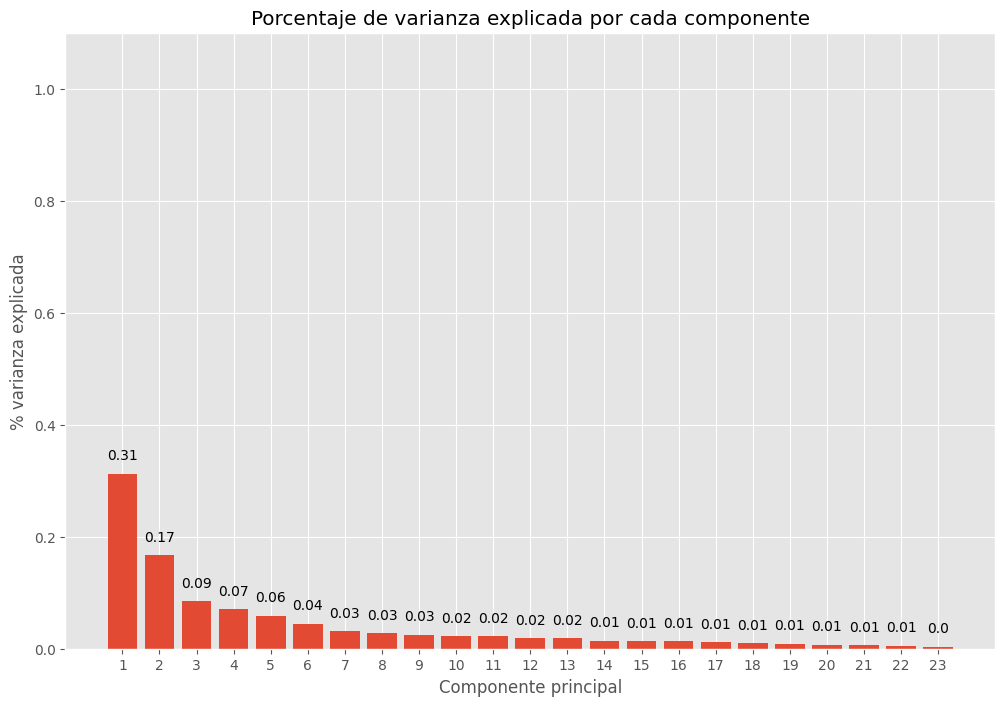

In [ ]:
# % de varianza explicada por cada componente

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))

# barras con la varianza explicada
ax.bar(x= np.arange(pca.n_components_) + 1, # pca.n_components_ devuelve el número de PCs generados
    height = pca.explained_variance_ratio_)

# etiquetas encima de cada barra
for x, y in zip(np.arange(pca.n_components_) + 1, pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(label,
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center')

ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('% varianza explicada')
plt.show()


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.3125111  0.47917612 0.56449832 0.63561572 0.69466103 0.73953892
 0.77033406 0.79752064 0.82289426 0.84551716 0.86746341 0.88651656
 0.90504278 0.91936803 0.93286501 0.94584362 0.95704645 0.96679102
 0.97608654 0.98355611 0.99049601 0.99615843 1.        ]


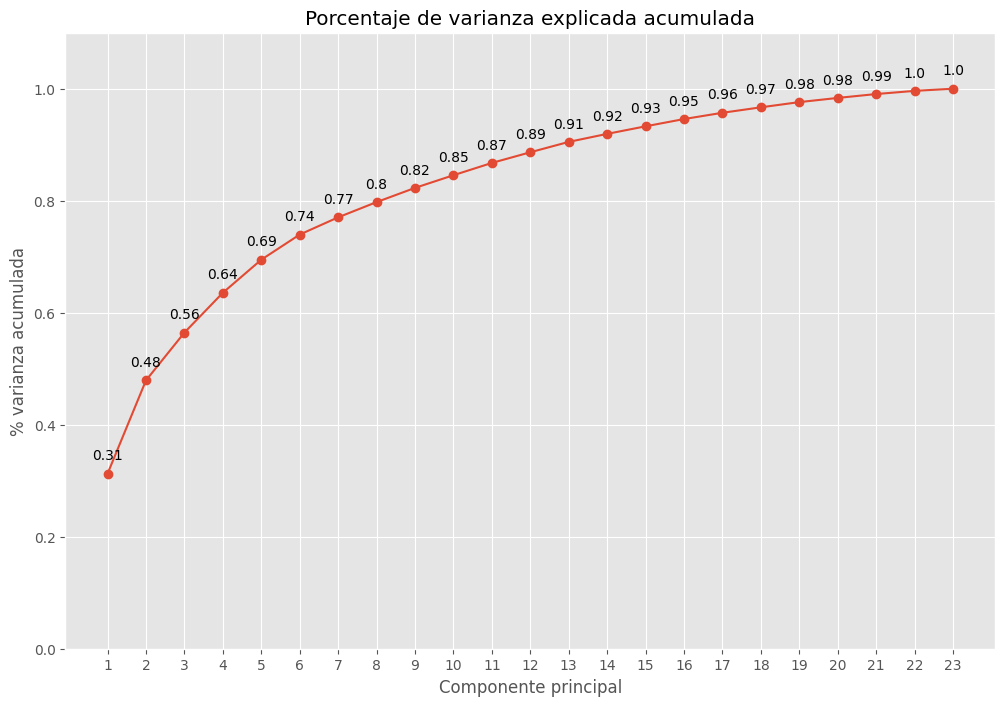

In [ ]:
# % de varianza explicada acumulada

prop_varianza_acum = pca.explained_variance_ratio_.cumsum()

print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))

ax.plot(np.arange(len(df.columns)) + 1,
    prop_varianza_acum,
    marker='o')

# etiquetas encima de cada punto
for x, y in zip(np.arange(len(df.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(label,
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center')

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('% varianza acumulada')

plt.show()

In [98]:
# Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

# en el anterior bloque de código hice:
# prop_varianza_acum = pca.explained_variance_ratio_.cumsum()
# ahora:

comp_70 = np.argmax(prop_varianza_acum >= 0.70) + 1
comp_75 = np.argmax(prop_varianza_acum >= 0.75) + 1

print(comp_70, comp_75)

6 7


In [ ]:
# para llegar al 70% de varianza explicada necesito 6 componentes
# para llegar al 75% de varianza explicada necesito 7 componentes

# si el objetivo es conservar entre el 70% y el 75% de la varianza original del dataset,
# sería adecuado quedarse con entre 6 y 7 componentes principales

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [99]:
X = 6

pca_red = PCA(n_components=X)
X_pca = pca_red.fit_transform(X_scaled)

# creo un df con los nuevos componentes principales
df_pca = pd.DataFrame(X_pca,
                      columns=[f"PC{i+1}" for i in range(X)])

df_pca.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876


In [103]:
# X = 7

pca_red = PCA(n_components=7)
X_pca = pca_red.fit_transform(X_scaled)

# creo un df con los nuevos componentes principales
df_pca = pd.DataFrame(X_pca,
                      columns=[f"PC{i+1}" for i in range(7)])

df_pca.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222,0.151252
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613,0.212474
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607,0.441633
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054,0.487040
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876,0.797944


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [108]:
# como eliminé la columna FoodGroup al principio cuando pedía que eliminara las columnas
# categóricas, tengo que recuperarla
df_original = pd.read_csv("data/nndb_flat.csv")


# ahora uno os PCs con la col FoodGroup del df original
df_pc_food = pd.concat([df_pca, df_original[['FoodGroup']].reset_index(drop=True)],axis=1)


In [109]:
# para cada PC, obtener los 3 FoodGroup con valores más altos
top_foodgroups = {}

for pc in df_pca.columns:
    top_foodgroups[pc] = (df_pc_food.groupby('FoodGroup')[pc]
                          .mean()
                          .sort_values(ascending=False)
                          .head(3))

top_foodgroups

{'PC1': FoodGroup
 Breakfast Cereals        4.020261
 Nut and Seed Products    3.120684
 Spices and Herbs         2.562117
 Name: PC1, dtype: float64,
 'PC2': FoodGroup
 Spices and Herbs         3.647736
 Breakfast Cereals        2.748076
 Nut and Seed Products    2.267573
 Name: PC2, dtype: float64,
 'PC3': FoodGroup
 Fats and Oils            2.333724
 Baked Products           1.727793
 Nut and Seed Products    1.241486
 Name: PC3, dtype: float64,
 'PC4': FoodGroup
 Breakfast Cereals    2.265027
 Fats and Oils        1.045026
 Beverages            0.545486
 Name: PC4, dtype: float64,
 'PC5': FoodGroup
 Fats and Oils             2.634166
 Dairy and Egg Products    1.555680
 Baby Foods                0.929960
 Name: PC5, dtype: float64,
 'PC6': FoodGroup
 Fats and Oils            2.054032
 Nut and Seed Products    1.762298
 Spices and Herbs         1.461075
 Name: PC6, dtype: float64,
 'PC7': FoodGroup
 Sweets                    0.738864
 Dairy and Egg Products    0.599987
 Nut and Seed

In [110]:
pd.DataFrame(top_foodgroups)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
FoodGroup,,,,,,,
Baby Foods,NaN,NaN,NaN,NaN,0.929960,NaN,NaN
Baked Products,NaN,NaN,1.727793,NaN,NaN,NaN,NaN
Beverages,NaN,NaN,NaN,0.545486,NaN,NaN,NaN
Breakfast Cereals,4.020261,2.748076,NaN,2.265027,NaN,NaN,NaN
Dairy and Egg Products,NaN,NaN,NaN,NaN,1.555680,NaN,0.599987
Fats and Oils,NaN,NaN,2.333724,1.045026,2.634166,2.054032,NaN
Nut and Seed Products,3.120684,2.267573,1.241486,NaN,NaN,1.762298,0.550021
Spices and Herbs,2.562117,3.647736,NaN,NaN,NaN,1.461075,NaN
Sweets,NaN,NaN,NaN,NaN,NaN,NaN,0.738864
